# Project: Loan Default using Gradient Boosting Decision Trees

## Introduction

### 1. Understand the dataset
- Column Descriptions: 
- V1: Customer ID 
- V2: If a customer has bounced in first EMI (1 : Bounced, 0 : Not bounced) 
- V3: Number of times bounced in recent 12 months 
- V4: Maximum MOB (Month of business with TVS Credit) #
- V5: Number of times bounced while repaying the loan #
- V6: EMI #
- V7: Loan Amount #
- V8: Tenure #
- V9: Dealer codes from where customer has purchased the Two wheeler #
- V10: Product code of Two wheeler (MC : Motorcycle , MO : Moped, SC : Scooter) #
- V11: No of advance EMI paid #
- V12: Rate of interest #
- V13: Gender (Male/Female) #
- V14: Employment type (HOUSEWIFE : housewife, SELF : Self-employed, SAL : Salaried, PENS : Pensioner, STUDENT : Student) #
- V15: Resident type of customer #
- V16: Date of birth #
- V17: Age at which customer has taken the loan #
- V18: Number of loans 
- V19: Number of secured loans 
- V20: Number of unsecured loans 
- V21: Maximum amount sanctioned in the Live loans #
- V22: Number of new loans in last 3 months 
- V23: Total sanctioned amount in the secured Loans which are Live #
- V24: Total sanctioned amount in the unsecured Loans which are Live #
- V25: Maximum amount sanctioned for any Two wheeler loan #
- V26: Time since last Personal loan taken (in months) #
- V27: Time since first consumer durables loan taken (in months) #
- V28: Number of times 30 days past due in last 6 months 
- V29: Number of times 60 days past due in last 6 months 
- V30: Number of times 90 days past due in last 3 months 
- V31: Tier ; (Customers geographical location) 
- V32: Target variable (1: Defaulters / 0: Non-Defaulters)<br><br>
- This dataset contain many of NULL.
- Data from OpenML: https://www.openml.org/search?type=data&status=active&id=43743&sort=runs

### 2. What is my objective?
- Find the most AUC score.

## Plans
1. Data Cleaning
2. EDA
3. Modeling
4. Result
5. Conclusion

## 0. Set library and datasets

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import math
from sklearn.feature_selection import f_classif

In [3]:
df = pd.read_csv(r"C:\Users\User\Downloads\TVS_Loan_Default.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_27460\1082226492.py:1: DtypeWarning: Columns (3,4,5,6,7,8,10,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\User\Downloads\TVS_Loan_Default.csv")


## 1. Scan & Cleaning Data

### 1.1 View data
- There is "?" which mean NaN, so we need to clean it by substitude "?" with NaN.

In [4]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,?,?,46500.0,?,?,0,0,0,'TIER 1',0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,?,?,28168.0,?,?,0,0,0,'TIER 1',0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,?,105000.0,38900.0,34.0,31.0,31,31,16,'TIER 1',0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,?,?,42900.0,?,?,0,0,0,'TIER 1',0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,?,?,40900.0,?,?,0,0,0,'TIER 1',0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119523,119524,0,1,?,?,?,?,?,?,?,...,?,?,?,?,?,0,0,0,'TIER 3',0
119524,119525,0,0,?,?,?,?,?,?,?,...,?,?,33000.0,?,?,3,1,0,'TIER 3',1
119525,119526,0,0,?,?,?,?,?,?,?,...,?,?,?,?,?,0,0,0,'TIER 3',0
119526,119527,0,1,?,?,?,?,?,?,?,...,?,31990.0,43600.0,?,13.0,0,0,0,'TIER 1',0


### 1.2 Check NULL & Duplicates
- Substitude "?" with NaN.
- There are many NULL or NaN, no duplicates.

In [5]:
df1 = df.replace("?", np.nan)
print(df1.isna().sum())

V1          0
V2          0
V3          0
V4      34480
V5      34480
V6      34480
V7      34480
V8      34480
V9      34480
V10     34480
V11     34480
V12     34480
V13     34480
V14     34480
V15     35397
V16     34480
V17     34480
V18         0
V19         0
V20         0
V21     82902
V22         0
V23    100247
V24    100500
V25     15061
V26    106097
V27     99095
V28         0
V29         0
V30         0
V31         0
V32         0
dtype: int64


In [6]:
df1.duplicated().sum()

0

### 1.3 Manage NULL
- There are so many null so I choose to drop columns that has NULL more than 10% in the columns.
- Drop 20 columns which a lot, but it important to do this way.

In [7]:
null_ratio = df1.isna().mean()
df_clean = df1.loc[:, null_ratio <= 0.10]

print("Before:", df1.shape)
print("After:", df_clean.shape)
print("Delete Columns:", df1.columns[null_ratio > 0.10].tolist())

Before: (119528, 32)
After: (119528, 12)
Delete Columns: ['V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27']


In [8]:
print(df_clean.isna().sum())

V1     0
V2     0
V3     0
V18    0
V19    0
V20    0
V22    0
V28    0
V29    0
V30    0
V31    0
V32    0
dtype: int64


### 1.4 Manage data type
- Drop "ID" because it just context, can't be use for modeling.
- Use label encoder on V31 which turn categorical to numerical for modeling

In [9]:
df2 = df_clean.drop(columns="V1")

In [10]:
le = LabelEncoder()

df3 = df2.copy()
df3['V31'] = le.fit_transform(df3['V31'])

print(df3['V31'].unique())
print(dict(zip(le.classes_, le.transform(le.classes_))))

[0 3 2 1]
{"'TIER 1'": 0, "'TIER 2'": 1, "'TIER 3'": 2, "'TIER 4'": 3}


### 1.5 Check default ratio
- Dataset is imbalanced, Gradient Boosting models are appropriate because they can handle it.

In [11]:
print(df3['V32'].value_counts(normalize=True) * 100)
print(df3['V32'].value_counts())

V32
0    97.813065
1     2.186935
Name: proportion, dtype: float64
V32
0    116914
1      2614
Name: count, dtype: int64


## 2. EDA

### 2.1 Plot
- V1: Customer ID 
- V2: If a customer has bounced in first EMI (1 : Bounced, 0 : Not bounced) 
- V3: Number of times bounced in recent 12 months 
- V18: Number of loans 
- V19: Number of secured loans 
- V20: Number of unsecured loans 
- V22: Number of new loans in last 3 months 
- V28: Number of times 30 days past due in last 6 months 
- V29: Number of times 60 days past due in last 6 months 
- V30: Number of times 90 days past due in last 3 months 
- V31: Tier ; (Customers geographical location) 
- V32: Target variable (1: Defaulters / 0: Non-Defaulters) <br><br>
- I choose to drop V22 because there only one value which not help model to learning.

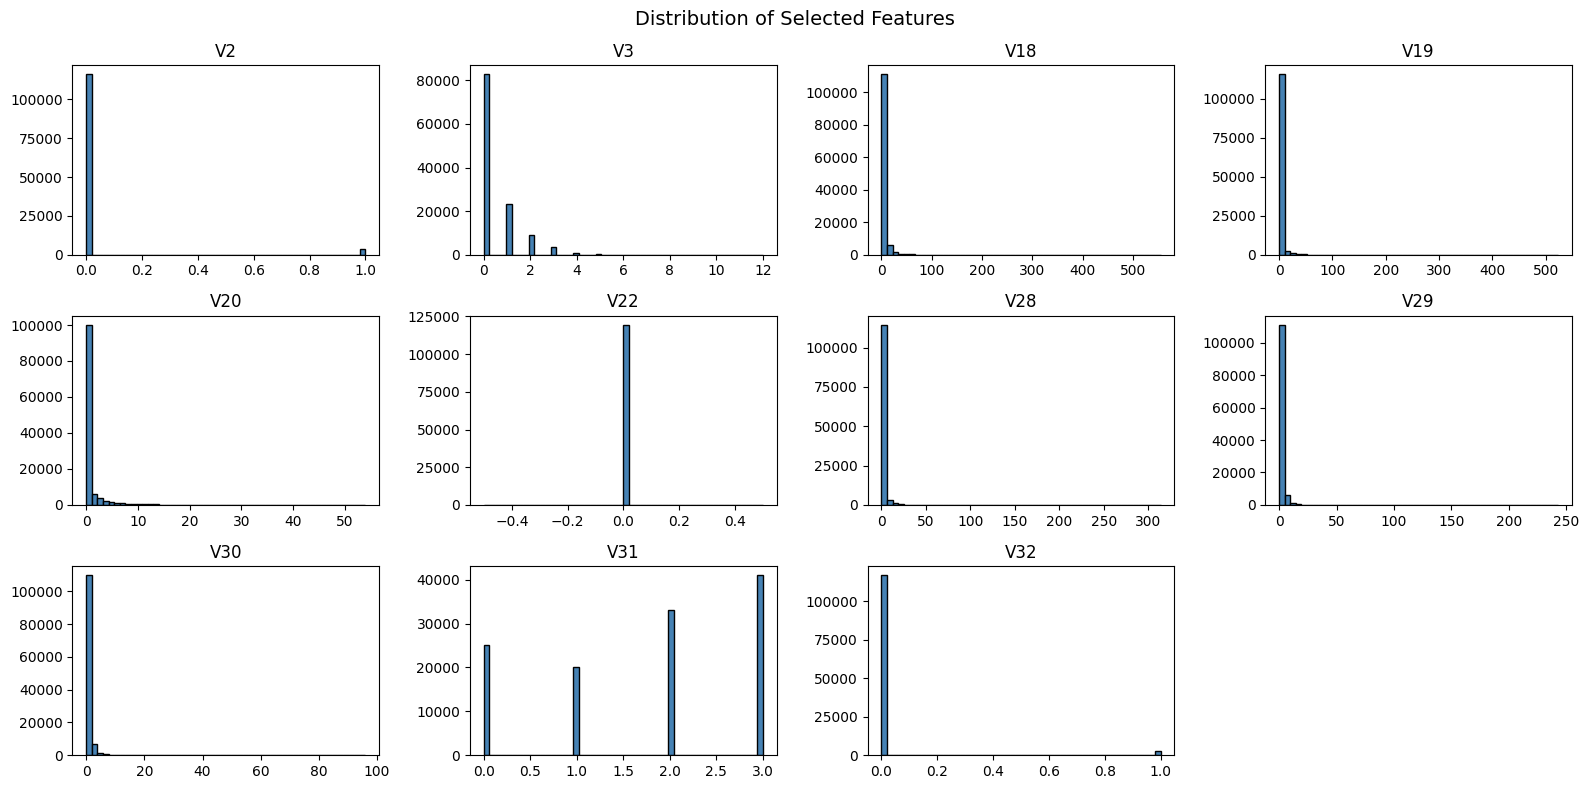

In [12]:
cols = ['V2','V3','V18','V19','V20','V22','V28','V29','V30','V31','V32']

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = axes.flatten() 

for i, col in enumerate(cols):
    df3[col].plot(kind='hist', bins=50, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Selected Features', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
df3["V22"].unique()

array([0], dtype=int64)

In [14]:
df4 = df3.drop(columns=["V22"])

### 2.2 Outliner

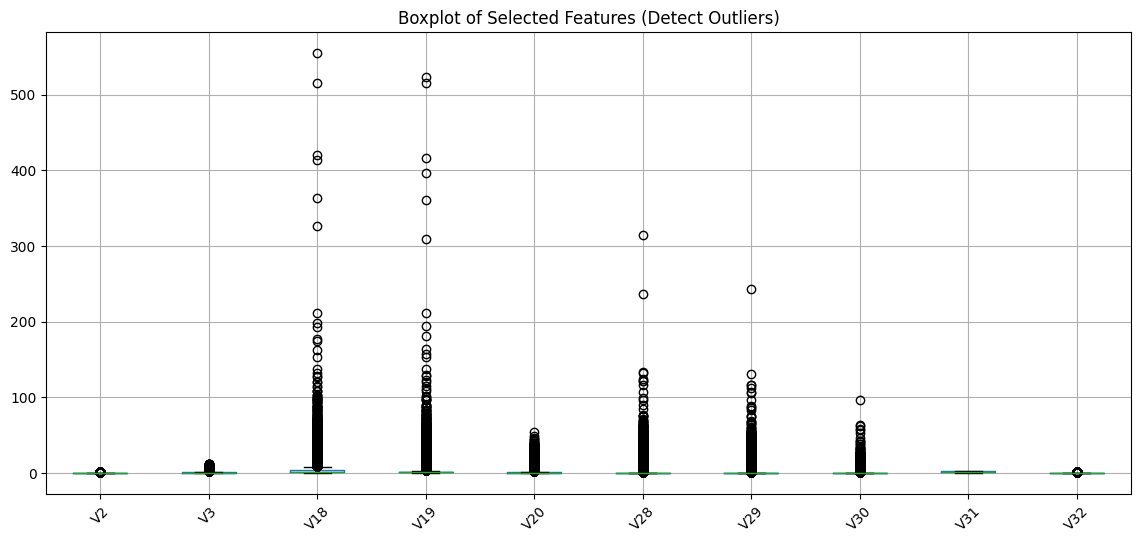

In [15]:
cols = ['V2','V3','V18','V19','V20','V28','V29','V30','V31','V32']

plt.figure(figsize=(14,6))
df4[cols].boxplot()
plt.title('Boxplot of Selected Features (Detect Outliers)')
plt.xticks(rotation=45)
plt.show()

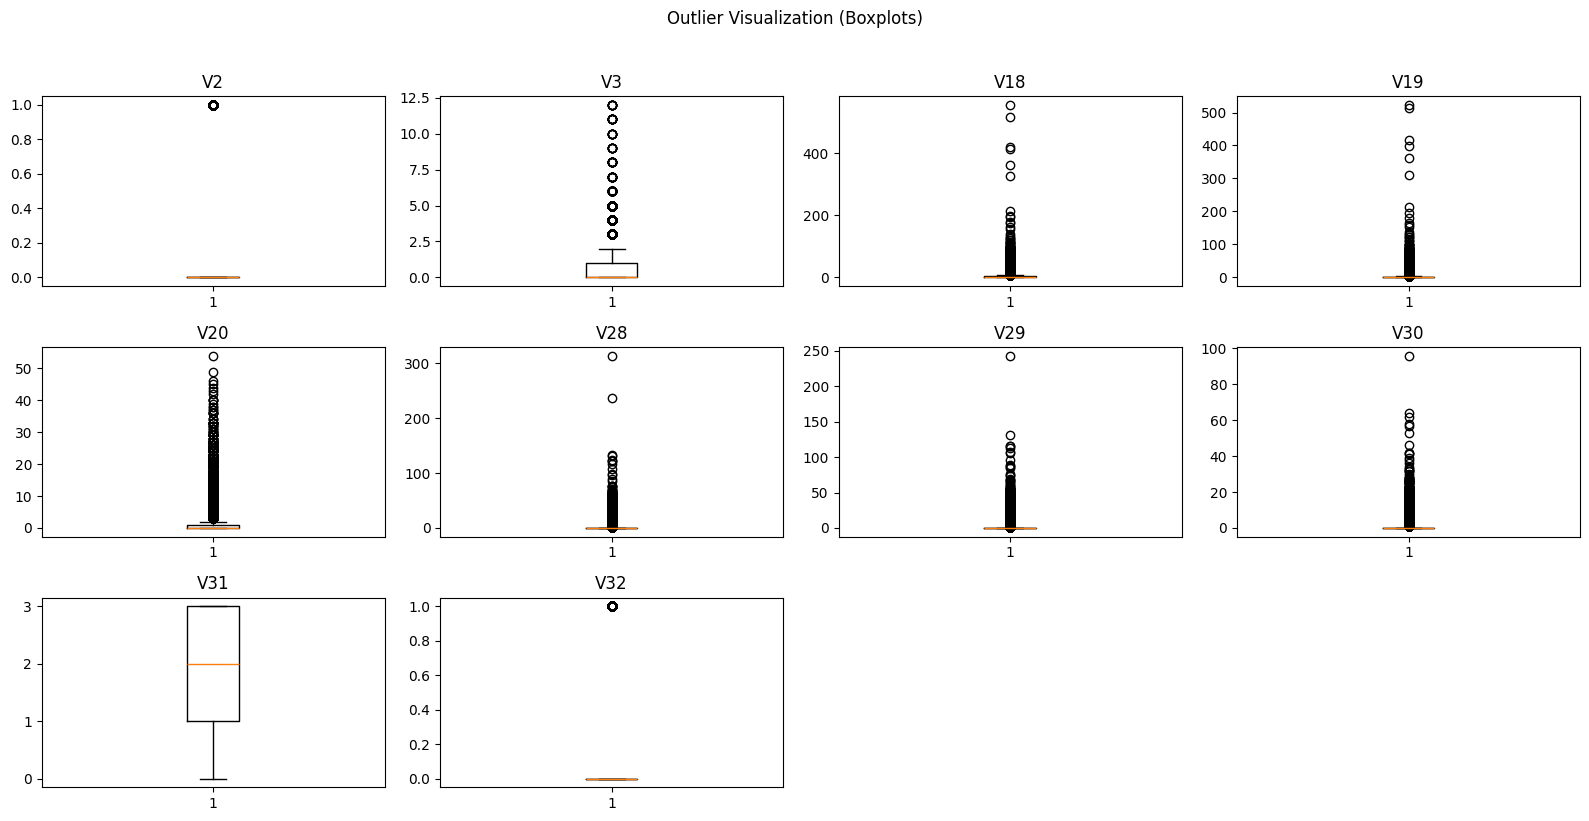

In [16]:
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = np.atleast_1d(axes).ravel()

for k, col in enumerate(cols):
    axes[k].boxplot(pd.to_numeric(df3[col], errors='coerce').dropna().values,
                    vert=True, whis=1.5, showfliers=True)
    axes[k].set_title(col)

for idx in range(len(cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Outlier Visualization (Boxplots)', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Correlation

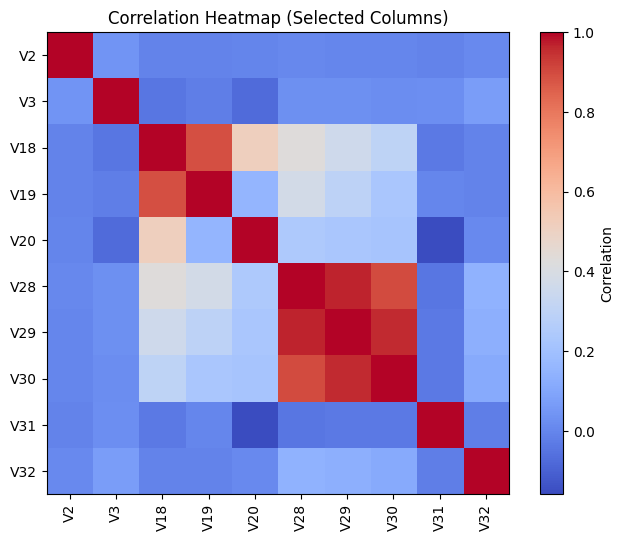

In [17]:
corr = df3[cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap (Selected Columns)')
plt.show()

### 2.4 Statistical Hypothesis Tests: Mean
- Only V18 isn't significant for predict V32, because p-value ~ 0.0753
- But I gonna keep it because it maybe control variable which mean it help other feature more good predict.

In [18]:
X = df4[['V2','V3','V18','V19','V20','V28','V29','V30','V31']]
y = df4['V32']

f_values, p_values = f_classif(X, y)

anova_result = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values('p-value')

print("If p-value > 0.05, that feature is siginificant for predict V32\n")
print(anova_result)

If p-value > 0.05, that feature is siginificant for predict V32

  Feature      F-Score        p-value
5     V28  2485.279125   0.000000e+00
6     V29  2181.310012   0.000000e+00
7     V30  1657.812691   0.000000e+00
1      V3   606.925319  1.127397e-133
8     V31    42.806136   6.068507e-11
0      V2    18.201354   1.988901e-05
4     V20    12.066740   5.134753e-04
3     V19     6.397485   1.142949e-02
2     V18     3.162100   7.536871e-02


## 3. Modeling with feature selection using Logistic regression, Decision tree, Random forest

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### 3.1 Feature selection strategy
- There are 3 strategy
- First, I will use 5 feature that has most p-value (V28, V29, V30, V3, V31).
- Second, I will use all significance p-value (exclude V18).
- Third, I will use all feature.

### 3.2 First strategy

In [20]:
## Modeling
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', n_jobs=None
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=50, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=20,
        n_jobs=-1, class_weight='balanced_subsample', random_state=42
    ),
    "Naive Bayes": GaussianNB()
}

## Training & Evaluation
def evaluate(clf, Xtr, Xte):
    clf.fit(Xtr, y_train)
    y_prob = clf.predict_proba(Xte)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

In [21]:
features = ['V28','V29','V30','V3','V31']
X = df4[features].copy()
y = df4['V32'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Scaler only for regression and bayes model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}

## Model that need Scaler
results["Logistic Regression"] = evaluate(models["Logistic Regression"], X_train_scaled, X_test_scaled)
results["Naive Bayes"]        = evaluate(models["Naive Bayes"],        X_train_scaled, X_test_scaled)

## Model that not need
results["Decision Tree"]      = evaluate(models["Decision Tree"],      X_train, X_test)
results["Random Forest"]      = evaluate(models["Random Forest"],      X_train, X_test)

## Descending sort by AUC
res_df = pd.DataFrame(results).T.sort_values("AUC", ascending=False)
print(res_df.round(4))

## Best model
best_name = res_df.index[0]
best_clf = models[best_name]
if "Logistic" in best_name or "Bayes" in best_name:
    best_clf.fit(X_train_scaled, y_train)
    y_pred = best_clf.predict(X_test_scaled)
else:
    best_clf.fit(X_train, y_train)
    y_pred = best_clf.predict(X_test)

## Save
S1_model = best_clf
S1_report = res_df.copy()

print(f"\n=== Classification report: {best_name} ===")
print(classification_report(y_test, y_pred, digits=4))

                        AUC      F1  Precision  Recall
Random Forest        0.7971  0.1433     0.0806  0.6424
Decision Tree        0.7950  0.1339     0.0743  0.6711
Logistic Regression  0.7745  0.1312     0.0733  0.6252
Naive Bayes          0.7343  0.1191     0.1009  0.1453

=== Classification report: Random Forest ===
              precision    recall  f1-score   support

           0     0.9905    0.8362    0.9068     23383
           1     0.0806    0.6424    0.1433       523

    accuracy                         0.8319     23906
   macro avg     0.5356    0.7393    0.5251     23906
weighted avg     0.9706    0.8319    0.8901     23906



### 3.3 Second Strategy

In [23]:
features = ['V2','V3','V19','V20','V28','V29','V30','V31']
X = df4[features].copy()
y = df4['V32'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Scaler only for regression and bayes model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}

## Model that need Scaler
results["Logistic Regression"] = evaluate(models["Logistic Regression"], X_train_scaled, X_test_scaled)
results["Naive Bayes"]        = evaluate(models["Naive Bayes"],        X_train_scaled, X_test_scaled)

## Model that not need
results["Decision Tree"]      = evaluate(models["Decision Tree"],      X_train, X_test)
results["Random Forest"]      = evaluate(models["Random Forest"],      X_train, X_test)

## Descending sort by AUC
res_df = pd.DataFrame(results).T.sort_values("AUC", ascending=False)
print(res_df.round(4))

## Best model
best_name = res_df.index[0]
best_clf = models[best_name]
if "Logistic" in best_name or "Bayes" in best_name:
    best_clf.fit(X_train_scaled, y_train)
    y_pred = best_clf.predict(X_test_scaled)
else:
    best_clf.fit(X_train, y_train)
    y_pred = best_clf.predict(X_test)

## Save
S2_model = best_clf
S2_report = res_df.copy()

print(f"\n=== Classification report: {best_name} ===")
print(classification_report(y_test, y_pred, digits=4))

                        AUC      F1  Precision  Recall
Decision Tree        0.8083  0.1374     0.0763  0.6883
Random Forest        0.8039  0.1617     0.0927  0.6348
Logistic Regression  0.7904  0.1383     0.0779  0.6176
Naive Bayes          0.7175  0.1151     0.0869  0.1702

=== Classification report: Decision Tree ===
              precision    recall  f1-score   support

           0     0.9915    0.8136    0.8938     23383
           1     0.0763    0.6883    0.1374       523

    accuracy                         0.8109     23906
   macro avg     0.5339    0.7510    0.5156     23906
weighted avg     0.9715    0.8109    0.8773     23906



### 3.4 Third Strategy

In [24]:
features = ['V2','V3','V18','V19','V20','V28','V29','V30','V31']
X = df4[features].copy()
y = df4['V32'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Scaler only for regression and bayes model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}

## Model that need Scaler
results["Logistic Regression"] = evaluate(models["Logistic Regression"], X_train_scaled, X_test_scaled)
results["Naive Bayes"]        = evaluate(models["Naive Bayes"],        X_train_scaled, X_test_scaled)

## Model that not need
results["Decision Tree"]      = evaluate(models["Decision Tree"],      X_train, X_test)
results["Random Forest"]      = evaluate(models["Random Forest"],      X_train, X_test)

## Descending sort by AUC
res_df = pd.DataFrame(results).T.sort_values("AUC", ascending=False)
print(res_df.round(4))

## Best model
best_name = res_df.index[0]
best_clf = models[best_name]
if "Logistic" in best_name or "Bayes" in best_name:
    best_clf.fit(X_train_scaled, y_train)
    y_pred = best_clf.predict(X_test_scaled)
else:
    best_clf.fit(X_train, y_train)
    y_pred = best_clf.predict(X_test)

## Save
S3_model = best_clf
S3_report = res_df.copy()

print(f"\n=== Classification report: {best_name} ===")
print(classification_report(y_test, y_pred, digits=4))

                        AUC      F1  Precision  Recall
Decision Tree        0.8153  0.1455     0.0813  0.6941
Random Forest        0.7998  0.1777     0.1036  0.6252
Logistic Regression  0.7904  0.1382     0.0778  0.6176
Naive Bayes          0.7194  0.1141     0.0854  0.1721

=== Classification report: Decision Tree ===
              precision    recall  f1-score   support

           0     0.9918    0.8246    0.9005     23383
           1     0.0813    0.6941    0.1455       523

    accuracy                         0.8217     23906
   macro avg     0.5365    0.7593    0.5230     23906
weighted avg     0.9719    0.8217    0.8840     23906



### 3.5 Result
- Best model is Decision tree from third strategy.
- Most AUC = 0.81533

In [25]:
print(S1_model)
print(S1_report)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=20,
                       n_estimators=300, n_jobs=-1, random_state=42)
                          AUC        F1  Precision    Recall
Random Forest        0.797074  0.143284   0.080634  0.642447
Decision Tree        0.795011  0.133867   0.074349  0.671128
Logistic Regression  0.774509  0.131194   0.073286  0.625239
Naive Bayes          0.734316  0.119122   0.100930  0.145315


In [26]:
print(S2_model)
print(S2_report)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50, random_state=42)
                          AUC        F1  Precision    Recall
Decision Tree        0.808298  0.137378   0.076304  0.688337
Random Forest        0.803928  0.161715   0.092660  0.634799
Logistic Regression  0.790412  0.138330   0.077888  0.617591
Naive Bayes          0.717510  0.115061   0.086914  0.170172


In [27]:
print(S3_model)
print(S3_report)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50, random_state=42)
                          AUC        F1  Precision    Recall
Decision Tree        0.815330  0.145549   0.081299  0.694073
Random Forest        0.799838  0.177717   0.103579  0.625239
Logistic Regression  0.790413  0.138182   0.077794  0.617591
Naive Bayes          0.719370  0.114141   0.085389  0.172084


### 4. Modeling with Gradient Boosting Decision Trees
- Use same feature like third strategy.

In [37]:
models = {
    "XGBoost": {
        "pipeline": Pipeline([("clf", XGBClassifier(
            eval_metric="logloss", use_label_encoder=False, random_state=77
        ))]),
        "space": {
            "clf__max_depth": Integer(5, 10),
            "clf__learning_rate": Real(0.01, 0.1, prior="log-uniform"),
            "clf__n_estimators": Integer(50, 300),
            "clf__subsample": Real(0.5, 1.0, prior="uniform"),
            "clf__colsample_bytree": Real(0.5, 1.0, prior="uniform"),
        },
    },
    "LightGBM": {
        "pipeline": Pipeline([("clf", LGBMClassifier(
            objective="binary", random_state=77, n_jobs=-1, verbose=-1
        ))]),
        "space": {
            "clf__num_leaves": Integer(16, 128),
            "clf__learning_rate": Real(0.01, 0.1, prior="log-uniform"),
            "clf__n_estimators": Integer(50, 400),
            "clf__min_child_samples": Integer(20, 200),
            "clf__subsample": Real(0.6, 1.0, prior="uniform"),
            "clf__colsample_bytree": Real(0.6, 1.0, prior="uniform"),
        },
    },
    "CatBoost": {
        "pipeline": Pipeline([("clf", CatBoostClassifier(
            loss_function="Logloss", eval_metric="AUC",
            random_state=77, verbose=False, allow_writing_files=False, thread_count=-1
        ))]),
        "space": {
            "clf__depth": Integer(4, 10),
            "clf__learning_rate": Real(0.01, 0.1, prior="log-uniform"),
            "clf__n_estimators": Integer(50, 400),
            "clf__l2_leaf_reg": Real(1.0, 10.0, prior="log-uniform"),
            "clf__bagging_temperature": Real(0.0, 1.0, prior="uniform"),
        },
    },
}

def bayes_fit(pipeline, space, X_train, y_train, n_iter=20, cv=5, scoring="roc_auc", random_state=77):
    opt = BayesSearchCV(
        estimator=pipeline,
        search_spaces=space,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        random_state=random_state,
        verbose=1
    )
    opt.fit(X_train, y_train)
    return opt

In [40]:
features = ['V2','V3','V18','V19','V20','V28','V29','V30','V31']
X = df4[features].copy()
y = df4['V32'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=77, stratify=y)

In [41]:
all_reports = {}
all_best = {}

for name, cfg in models.items():
    print(f"\n====== {name} ======")
    opt = bayes_fit(cfg["pipeline"], cfg["space"], X_train, y_train, n_iter=20, cv=5, scoring="roc_auc", random_state=77)

    best_model = opt.best_estimator_
    y_scores   = best_model.predict_proba(X_test)[:, 1]
    y_pred     = (y_scores >= 0.5).astype(int)

    report = {
        "best_params": opt.best_params_,
        "AUC": roc_auc_score(y_test, y_scores),
        "clf": best_model
    }
    all_reports[name] = report
    all_best[name]    = best_model

## Best model
winner_name = max(all_reports, key=lambda k: all_reports[k]["AUC"])
winner_clf  = all_best[winner_name]
print(f"\n🏆 Winner: {winner_name} | AUC = {all_reports[winner_name]['AUC']:.4f}")


====== XGBoost ======
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 can

c:\Users\User\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:51:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



====== LightGBM ======
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 ca

In [49]:
Boosting_Winner = all_reports[winner_name]['AUC']
print(f"The Boosting_Winner is {winner_name}, AUC = {Boosting_Winner}")

The Boosting_Winner is CatBoost, AUC = 0.8418008327371564


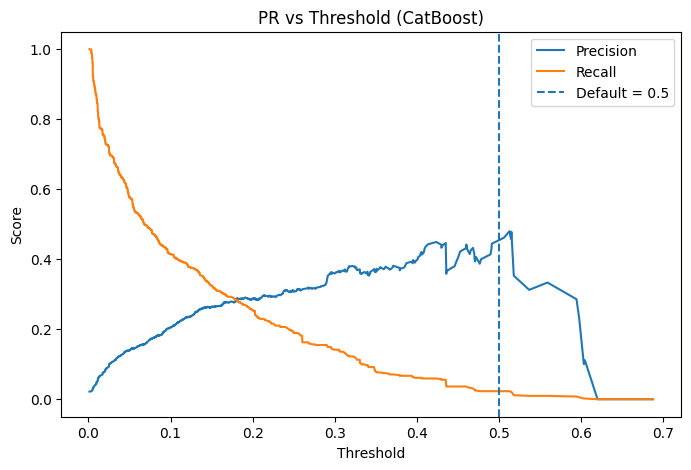

In [50]:
y_scores_win = winner_clf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_win)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1],   label="Recall")
plt.axvline(x=0.5, linestyle="--", label="Default = 0.5")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title(f"PR vs Threshold ({winner_name})")
plt.legend(); plt.show()

## 4. Result
- Best model along the objective is CatBoost with AUC = 0.8418

In [53]:
print(S1_report,"\n")
print(S2_report,"\n")
print(S3_report,"\n")
print(f"{winner_name}, AUC = {Boosting_Winner}")

                          AUC        F1  Precision    Recall
Random Forest        0.797074  0.143284   0.080634  0.642447
Decision Tree        0.795011  0.133867   0.074349  0.671128
Logistic Regression  0.774509  0.131194   0.073286  0.625239
Naive Bayes          0.734316  0.119122   0.100930  0.145315 

                          AUC        F1  Precision    Recall
Decision Tree        0.808298  0.137378   0.076304  0.688337
Random Forest        0.803928  0.161715   0.092660  0.634799
Logistic Regression  0.790412  0.138330   0.077888  0.617591
Naive Bayes          0.717510  0.115061   0.086914  0.170172 

                          AUC        F1  Precision    Recall
Decision Tree        0.815330  0.145549   0.081299  0.694073
Random Forest        0.799838  0.177717   0.103579  0.625239
Logistic Regression  0.790413  0.138182   0.077794  0.617591
Naive Bayes          0.719370  0.114141   0.085389  0.172084 

CatBoost, AUC = 0.8418008327371564


## 5. Conclusion
1. There are many missing value, so I need to drop many columns.
2. For traditional model, careful to select feature, it help faster calculation & good prediction. 
3. In this case, outliner & correlation isn't good enough for feature selection method, so I use ANOVA instead.
4. Boosting models are best suited for this type of data.
5. CatBoost is best with AUC = 0.8418